In [2]:
import numpy as np
import scipy as sp
import qutip as qt
import pandas as pd
import cvxpy as cp

np.set_printoptions(precision=4, suppress=True ,linewidth=np.inf, floatmode='fixed')


import matplotlib.pyplot as plt

## Parameters 
let k_b = 1

**main parameters** : $\lambda$, $\theta$ 

**fixed parameters** : $\epsilon$, g(coupling strengh), $\beta$ , real time interval

In [3]:
lamb = np.linspace(0,1,50)
theta = np.linspace(0,1,50)

eps = 2
g = 3
beta_a = 1
beta_b = 2
beta = 1.5
t = np.linspace(0,1,1000)


## Matrices

Basis : Fock basis

**Hamiltonian** : 12*12 Matrix

**Bell states** : 4*4 Matrix

#### Create Hamiltonian

In [4]:
mat_crea2 = np.array([[0,0],[1,0]])
mat_anni2 = np.array([[0,1],[0,0]]) 
mat_id2 = np.identity(2)

mat_crea3 = np.array([[0,0,0],[1,0,0],[0,np.sqrt(2),0]])
mat_anni3 = np.array([[0,1,0],[0,0,np.sqrt(2)],[0,0,0]])
mat_id3 = np.identity(3)

diag_Ham = np.kron(np.kron(mat_id2,mat_id2),[[0,0,0],[0,1,0],[0,0,2]])
diag_Ham += np.kron(np.kron(mat_id2,[[0,0],[0,1]]),mat_id3)
diag_Ham += np.kron(np.kron([[0,0],[0,1]],mat_id2),mat_id3)

diag_Ham *= eps


offdiag_Ham1 = g * np.kron(np.kron(mat_crea2,mat_id2),mat_anni3)
offdiag_Ham2 = g * np.kron(np.kron(mat_anni2,mat_id2),mat_crea3)
offdiag_Ham3 = g * np.kron(np.kron(mat_id2,mat_crea2),mat_anni3)
offdiag_Ham4 = g * np.kron(np.kron(mat_id2,mat_anni2),mat_crea3)

offdiag_Ham = offdiag_Ham1 + offdiag_Ham2 + offdiag_Ham3 + offdiag_Ham4

Ham = diag_Ham + offdiag_Ham

c:\Users\128kbps\anaconda3\envs\workspace\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


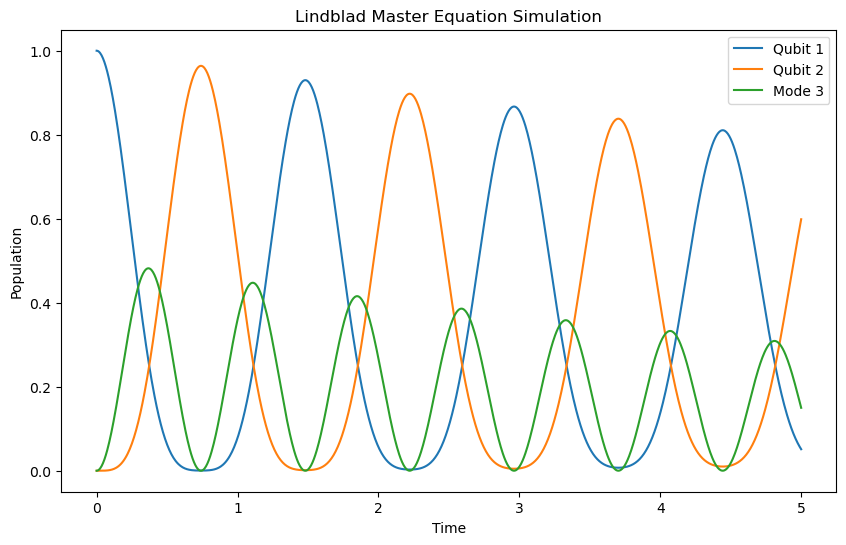

In [22]:
# QuTiP의 mesolve를 이용한 린드블라드 마스터 방정식 풀이

# 1. Hamiltonian을 QuTiP Qobj로 변환 및 차원 설정
H_qobj = qt.Qobj(Ham)
H_qobj.dims = [[2, 2, 3], [2, 2, 3]]

# 2. 초기 상태 설정 (예: 첫 번째 큐비트 Excited, 나머지 Ground)
psi0 = qt.tensor(qt.basis(2, 1), qt.basis(2, 0), qt.basis(3, 0))
rho0 = qt.ket2dm(psi0)

# 3. 붕괴 연산자(Collapse Operators) 설정
# 예시: 3번째 모드(Cavity)의 감쇠 (Damping)
kappa = 0.2
c_op = qt.tensor(qt.qeye(2), qt.qeye(2), qt.destroy(3))
c_ops = [np.sqrt(kappa) * c_op]

# 4. 시간 범위 설정
tlist = np.linspace(0, 5, 1000)

# 5. 기대값 계산을 위한 연산자 설정 (각 모드의 입자 수)
n1 = qt.tensor(qt.num(2), qt.qeye(2), qt.qeye(3))
n2 = qt.tensor(qt.qeye(2), qt.num(2), qt.qeye(3))
n3 = qt.tensor(qt.qeye(2), qt.qeye(2), qt.num(3))
e_ops = [n1, n2, n3]

# 6. 마스터 방정식 풀기
result = qt.mesolve(H_qobj, rho0, tlist, c_ops, e_ops)

# 7. 결과 그래프 그리기
plt.figure(figsize=(10,6))
plt.plot(tlist, result.expect[0], label='Qubit 1')
plt.plot(tlist, result.expect[1], label='Qubit 2')
plt.plot(tlist, result.expect[2], label='Mode 3')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.title('Lindblad Master Equation Simulation')
plt.show()

##### Bellstates

In [11]:
# 1. Ket 벡터 생성
ket_phi_plus = qt.bell_state('00') # (|00> + |11>) / sqrt(2)
ket_psi_minus = qt.bell_state('11') # (|01> - |10>) / sqrt(2)

# 2. 밀도 행렬(Density Matrix)로 변환 (|psi><psi|)
dm_phi_plus = qt.ket2dm(ket_phi_plus)
dm_psi_minus = qt.ket2dm(ket_psi_minus)

# 3. [중요] NumPy 배열로 변환 (사용자님 코드와 호환되게)
mat_phi_plu = dm_phi_plus.full()
mat_psi_min = dm_psi_minus.full()

print("Shape:", mat_phi_plu.shape) # (4, 4) 여야 함

Shape: (4, 4)


##### Hamiltonian for state $\rho_A$

In [12]:
Ham_part = np.array([[0,0],[0,1]])
Ham_part *= eps

sta_cav = np.array([[1,0,0],[0,0,0],[0,0,0]])

Ham_AB = (np.kron(Ham_part,np.identity(2)) + np.kron(np.identity(2),Ham_part))

#### Matrix calculation function

In [13]:
def Gibb(beta,mat):
    Gib = sp.linalg.expm(-beta * mat)
    Part_func = np.trace(Gib)

    return Gib/Part_func

In [14]:
def Tra_A(Mat,n):
    if n == 0:
        tens = Mat.reshape(2,2,2,2)
        trac = np.einsum('ijlj->il', tens)
    else:
        tens = Mat.reshape(2,2,n,2,2,n)
        trac = np.einsum('ijkljk->il', tens)
    return trac


def Tra_B(Mat,n):
    if n == 0:
        tens = Mat.reshape(2,2,2,2)
        trac = np.einsum('ijil->jl', tens)
    else:
        tens = Mat.reshape(2,2,n,2,2,n)
        trac = np.einsum('ijkilk->jl', tens)
    return trac

# System A: B의 인덱스를 Trace (B_row와 B_col이 같아야 함)
H_b = Tra_A(Gibb(beta_a,Ham),3)

# System B: A의 인덱스를 Trace (A_row와 A_col이 같아야 함)
H_a = Tra_B(Gibb(beta_b,Ham),3)

In [15]:
print(Gibb(beta,Ham))
print(H_a)

[[ 0.0055  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]
 [ 0.0000  0.0791  0.0000 -0.0559  0.0000  0.0000 -0.0559  0.0000  0.0000  0.0000  0.0000  0.0000]
 [ 0.0000  0.0000  0.2769  0.0000 -0.2398  0.0000  0.0000 -0.2398  0.0000  0.1958  0.0000  0.0000]
 [ 0.0000 -0.0559  0.0000  0.0397  0.0000  0.0000  0.0394  0.0000  0.0000  0.0000  0.0000  0.0000]
 [ 0.0000  0.0000 -0.2398  0.0000  0.2077  0.0000  0.0000  0.2076  0.0000 -0.1696  0.0000  0.0000]
 [ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0014  0.0000  0.0000  0.0014  0.0000 -0.0019  0.0000]
 [ 0.0000 -0.0559  0.0000  0.0394  0.0000  0.0000  0.0397  0.0000  0.0000  0.0000  0.0000  0.0000]
 [ 0.0000  0.0000 -0.2398  0.0000  0.2076  0.0000  0.0000  0.2077  0.0000 -0.1696  0.0000  0.0000]
 [ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0014  0.0000  0.0000  0.0014  0.0000 -0.0019  0.0000]
 [ 0.0000  0.0000  0.1958  0.0000 -0.1696  0.0000  0.0000 -0.1696  0.0000  0.1384  0.0000  0.0000]
 [ 0.0000 

#### Calculate $\rho_{AB}$

In [16]:
def Cal_rho(lamb_index,theta_index):
    rho = (1-lamb[lamb_index]- theta[theta_index])*np.kron(H_a,H_b) + lamb[lamb_index] * mat_phi_plu + theta[theta_index] * mat_psi_min
    return rho

In [17]:
np.trace(Cal_rho(42,2))

np.complex128(1.0000000000000004+0j)

#### Unitary design

In [18]:
Unit = sp.linalg.expm(-1j * Ham * (np.cumsum(t)*(t[1]-t[0]))[-1])

Optimal unit

In [2]:
def get_optimal_unitary(rho_AB, H_A, H_B, tol=1e-9):
    """
    논문의 Theorem 1에 따라 로컬 에너지 E_A를 최소화하는 최적의 Unitary U_*를 반환합니다.
    
    Args:
        rho_AB (np.ndarray): 초기 상태 밀도 행렬 (d_A * d_B, d_A * d_B)
        H_A (np.ndarray): 시스템 A의 해밀토니안 (d_A, d_A)
        H_B (np.ndarray): 시스템 B의 해밀토니안 (d_B, d_B)
        tol (float): 에너지 준위가 같다고 판단할 허용 오차
        
    Returns:
        U_opt (np.ndarray): 최적 유니터리 행렬
    """
    # 1. 차원 확인 및 전체 해밀토니안 구성
    dim_A = H_A.shape[0]
    dim_B = H_B.shape[0]
    dim_tot = dim_A * dim_B
    
    I_A = np.eye(dim_A)
    I_B = np.eye(dim_B)
    
    H_tot = np.kron(H_A, I_B) + np.kron(I_A, H_B)
    H_A_tot = np.kron(H_A, I_B) # 전체 공간에서의 H_A 연산자
    
    # 2. 전체 해밀토니안 대각화하여 에너지 고유기저 찾기
    eigvals_tot, eigvecs_tot = np.linalg.eigh(H_tot)
    
    # 3. 에너지가 같은 부분공간(Degenerate Subspaces)으로 그룹화
    # np.unique 등을 사용해 그룹 인덱싱
    # round를 통해 수치적 오차 보정
    energies_rounded = np.round(eigvals_tot / tol) * tol
    unique_energies = np.unique(energies_rounded)
    
    U_opt = np.zeros((dim_tot, dim_tot), dtype=complex)
    
    for E in unique_energies:
        # 해당 에너지 E를 가지는 인덱스들 찾기
        indices = np.where(np.abs(energies_rounded - E) < tol)[0]
        
        if len(indices) == 0:
            continue
            
        # 부분공간의 기저 벡터들 (Global Energy Eigenbasis)
        subspace_basis = eigvecs_tot[:, indices] # shape: (dim_tot, block_dim)
        
        # 4. 블록 내의 밀도 행렬(rho) 대각화
        # rho_block = P^dag @ rho @ P
        rho_block = subspace_basis.conj().T @ rho_AB @ subspace_basis
        
        p_nu, v_rho = np.linalg.eigh(rho_block)
        
        # 확률(p_nu)은 내림차순 정렬 (큰 확률 -> 작은 확률)
        # eigh는 오름차순으로 반환하므로 뒤집음
        sorted_p_indices = np.argsort(p_nu)[::-1]
        p_nu_sorted = p_nu[sorted_p_indices]
        v_rho_sorted = v_rho[:, sorted_p_indices]
        
        # |phi_n>: 전체 힐베르트 공간에서 rho의 고유상태들
        phi_n_states = subspace_basis @ v_rho_sorted
        
        # 5. 블록 내의 H_A 대각화 (Local Energy Sorting)
        # H_A_block = P^dag @ (H_A x I) @ P
        H_A_block = subspace_basis.conj().T @ H_A_tot @ subspace_basis
        
        e_A_vals, v_HA = np.linalg.eigh(H_A_block)
        
        # A의 에너지는 오름차순 정렬 (작은 에너지 -> 큰 에너지)
        # 목적: 확률이 큰 상태(High Prob)를 에너지가 작은 상태(Low Energy)로 보냄 -> 에너지 최소화
        sorted_e_indices = np.argsort(e_A_vals) # Default is ascending
        e_A_sorted = e_A_vals[sorted_e_indices]
        v_HA_sorted = v_HA[:, sorted_e_indices]
        
        # |epsilon_n>: 전체 힐베르트 공간에서 정렬된 에너지 기저들
        epsilon_n_states = subspace_basis @ v_HA_sorted
        
        # 6. 부분공간 유니터리 구성: sum |epsilon><phi|
        # U_sub = sum_n |epsilon_n^nu> <phi_n^nu|
        U_sub = epsilon_n_states @ phi_n_states.conj().T
        
        U_opt += U_sub
        
    return U_opt

In [42]:
U_opt = get_optimal_unitary(Cal_rho(1,1),H_a,H_b).real

In [43]:
exten = np.kron(U_opt,np.identity(3))

In [51]:
A = [[0,1,2],[1,1,0],[1,0,1]]

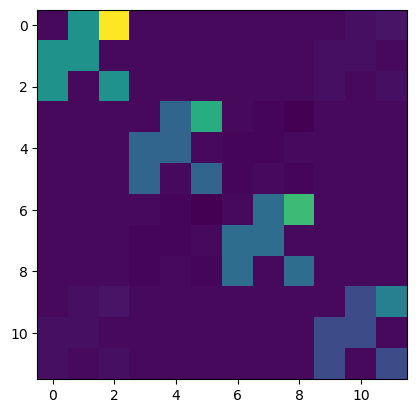

: 

In [ ]:
plt.imshow(np.kron(Cal_rho(1,1),np.array(A)).real)
plt.show()

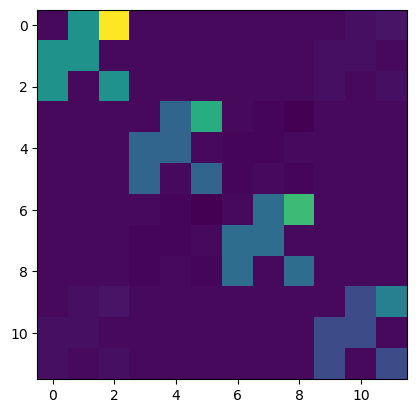

In [48]:
plt.imshow((exten @ np.kron(Cal_rho(1,1),A) @ exten.conj().T).real)
plt.show()

In [25]:
Cal_rho(1,1)

array([[ 0.3693+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0102+0.0000j],
       [ 0.0000+0.0000j,  0.2264+0.0000j, -0.0102+0.0000j,  0.0000+0.0000j],
       [ 0.0000+0.0000j, -0.0102+0.0000j,  0.2498+0.0000j,  0.0000+0.0000j],
       [ 0.0102+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j,  0.1545+0.0000j]])

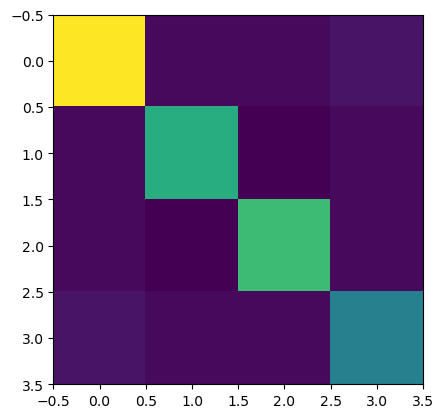

In [38]:
plt.imshow((U_opt @ Cal_rho(1,1) @ U_opt.conj().T).real)
plt.show()

In [32]:
np.kron(H_a,np.identity(3))

array([[0.5998, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
       [0.0000, 0.5998, 0.0000, 0.0000, 0.0000, 0.0000],
       [0.0000, 0.0000, 0.5998, 0.0000, 0.0000, 0.0000],
       [0.0000, 0.0000, 0.0000, 0.4002, 0.0000, 0.0000],
       [0.0000, 0.0000, 0.0000, 0.0000, 0.4002, 0.0000],
       [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.4002]])

#### Calculate $\sigma_{AB}$

In [19]:
def Cal_sig(li,tl):
    #rho_AB를 sigma_AB로 계산하는 함수
    sig = Unit @ np.kron(Cal_rho(li,tl),sta_cav) @ np.conj(Unit).T
    return sig

In [ ]:
def Energy_A(li,tl):
    sigma = Cal_sig(1,1)
    sigma

array([[ 0.3693+0.0000j,  0.0000+0.0000j,  0.0037-0.0081j,  0.0000+0.0000j,  0.0019+0.0009j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0019+0.0009j,  0.0000+0.0000j, -0.0016+0.0035j,  0.0000+0.0000j,  0.0000+0.0000j],
       [ 0.0000+0.0000j,  0.1651+0.0000j,  0.0000+0.0000j,  0.0000+0.0790j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0650j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j],
       [ 0.0037+0.0081j,  0.0000+0.0000j,  0.1187+0.0000j,  0.0000+0.0000j,  0.0000+0.0282j,  0.0000+0.0000j,  0.0000+0.0000j, -0.0000+0.0282j,  0.0000+0.0000j, -0.0515-0.0000j,  0.0000+0.0000j,  0.0000+0.0000j],
       [ 0.0000+0.0000j,  0.0000-0.0790j,  0.0000+0.0000j,  0.1617+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j, -0.0928-0.0000j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j],
       [ 0.0019-0.0009j,  0.0000+0.0000j,  0.0000-0.0282j,  0.0000+0.0000j,  0.0067+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0067+0.0000j,  0.0

#### Calculate $E(\rho_A)$
(D6)

In [ ]:
#rho_AB에서 partial trace와 자체 해밀토니안을 이용해 rho_A를 만드는 과정. 
E_final = np.trace(Ham_part @ Tra_B(Cal_rho(1,1),0)).real

In [66]:
dataset = np.zeros((len(theta),len(lamb)))

for i in range(len(theta)):
    for j in range(len(lamb)):
        E_final = np.trace(Ham_part @ Tra_B(Cal_rho(i,j),0)).real
        dataset[i][j] = E_final

In [70]:
np.savetxt('./cv.txt',dataset)

Calculate $S(\rho_{AB})$
(D7)

In [86]:
dataset2 = np.zeros((len(theta),len(lamb)))

for i in range(len(theta)):
    for j in range(len(lamb)): 
        rho_obj = qt.Qobj(Cal_rho(i, j).real)
        rho_A_fin = qt.entropy_vn(rho_obj)
        dataset2[i][j] = rho_A_fin

In [91]:
dataset2

array([[1.3351, 1.3365, 1.3367, ..., 0.1707, 0.0963, 0.0000],
       [1.3365, 1.3383, 1.3389, ..., 0.1830, 0.0996, 0.0688],
       [1.3366, 1.3388, 1.3397, ..., 0.1705, 0.1437, 0.1164],
       ...,
       [0.1680, 0.1815, 0.1705, ..., 0.4524, 0.4446, 0.4365],
       [0.0946, 0.0996, 0.1450, ..., 0.4451, 0.4376, 0.4297],
       [0.0000, 0.0701, 0.1186, ..., 0.4375, 0.4302, 0.4225]], shape=(50, 50))

In [87]:
np.savetxt('./entcv.txt',dataset2)

##### Calculate $E(\rho_{AB})$
(D8)

In [98]:
dataset3 = np.zeros((len(theta),len(lamb)))

for i in range(len(theta)):
    for j in range(len(lamb)):
        dataset3[i][j] = np.trace(Ham_AB @ Cal_rho(i,j))

C:\Users\128kbps\AppData\Local\Temp\ipykernel_468440\1694995241.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  dataset3[i][j] = np.trace(Ham_AB @ Cal_rho(i,j))


In [99]:
np.savetxt('./engcv.txt',dataset3)  

### (D6) Calculation

In [96]:
cvdata = pd.read_csv('./cv.txt',header=None,delim_whitespace=True)
entdata = pd.read_csv('./entcv.txt',header=None,delim_whitespace=True)
engdata = pd.read_csv('./engcv.txt',header=None,delim_whitespace=True)

C:\Users\128kbps\AppData\Local\Temp\ipykernel_468440\2861822718.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  cvdata = pd.read_csv('./cv.txt',header=None,delim_whitespace=True)
C:\Users\128kbps\AppData\Local\Temp\ipykernel_468440\2861822718.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  entdata = pd.read_csv('./entcv.txt',header=None,delim_whitespace=True)
C:\Users\128kbps\AppData\Local\Temp\ipykernel_468440\2861822718.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  engdata = pd.read_csv('./engcv.txt',header=None,delim_whitespace=True)


In [112]:
def C_Tra_B(Mat, n):
    """
    CVXPY 변수에 대해 부분 대각합(Partial Trace)을 수행하는 함수.
    
    Args:
        Mat: cvxpy.Variable 또는 표현식 (행렬)
        n: 시스템 차원 파라미터
           n=0일 때: 2x2 시스템 (4x4 행렬)에서 첫 번째 2차원 시스템을 Trace out.
           n>0일 때: 2x2xn 시스템 (4n x 4n 행렬)에서 첫 번째(2)와 세 번째(n) 시스템을 Trace out.
    Returns:
        cvxpy.Expression: 부분 대각합 결과 (2x2 행렬)
    """
    if n == 0:
        # 2x2 시스템 (총 차원 4)
        # dims=(2, 2)에서 axis=0 (첫 번째 시스템)을 Trace out
        return cp.partial_trace(Mat, (2, 2), 0)
    else:
        # 2x2xn 시스템 (총 차원 4n)
        # dims=(2, 2, n)에서 axis=0(첫 번째)과 axis=2(세 번째)를 Trace out 해야 함.
        # cvxpy에서는 한 번에 하나의 축만 Trace out 하는 것이 안전하므로 단계별로 수행합니다.
        
        # 1단계: 세 번째 시스템(n) Trace out -> 결과는 4x4 행렬 (2x2 시스템)
        rho_AB = cp.partial_trace(Mat, (2, 2, n), 2)
        
        # 2단계: 첫 번째 시스템(2) Trace out -> 결과는 2x2 행렬
        return cp.partial_trace(rho_AB, (2, 2), 0)

In [113]:
for i in range(5):
    for j in range(5):
        X = cp.Variable((4,4), PSD=True)
        # The operator >> denotes matrix inequality.
        
        constraints = [
            cp.von_neumann_entr(X) >= entdata [i][j],
            cp.trace(Ham_AB @ X) == engdata[i][j]        
        ]
        prob = cp.Problem(cp.Minimize(cp.trace(Ham_part @ C_Tra_B(X,0))-cvdata[i][j]),
                        constraints)
        prob.solve()

        # Print result.
        print("The optimal value is", prob.value)
        print("A solution X is")
        print(X.value)

The optimal value is -0.0012824078707790454
A solution X is
[[0.3679 0.0000 0.0000 0.0000]
 [0.0000 0.2237 0.0000 0.0000]
 [0.0000 0.0000 0.2493 0.0000]
 [0.0000 0.0000 0.0000 0.1515]]
The optimal value is -0.011122954630220394
A solution X is
[[0.3679 0.0000 0.0000 0.0000]
 [0.0000 0.2201 0.0000 0.0000]
 [0.0000 0.0000 0.2551 0.0000]
 [0.0000 0.0000 0.0000 0.1527]]
The optimal value is -0.031870671397766115
A solution X is
[[0.3679 0.0000 0.0000 0.0000]
 [0.0000 0.2116 0.0000 0.0000]
 [0.0000 0.0000 0.2668 0.0000]
 [0.0000 0.0000 0.0000 0.1534]]
The optimal value is -0.055156397040686866
A solution X is
[[0.3679 0.0000 0.0000 0.0000]
 [0.0000 0.2021 0.0000 0.0000]
 [0.0000 0.0000 0.2800 0.0000]
 [0.0000 0.0000 0.0000 0.1538]]
The optimal value is -0.07919024021001353
A solution X is
[[0.3679 0.0000 0.0000 0.0000]
 [0.0000 0.1925 0.0000 0.0000]
 [0.0000 0.0000 0.2940 0.0000]
 [0.0000 0.0000 0.0000 0.1539]]
The optimal value is -0.010724648699022787
A solution X is
[[0.3679 0.0000 0.000

In [ ]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# 1. 차원 설정 (A=2, B=2, C=3)
# QuTiP 5에서는 Tensor product 구조를 명확히 하기 위해 dims를 [[row_dims], [col_dims]] 형태로 지정하는 것이 좋습니다.
dims_composite = [[2, 2, 3], [2, 2, 3]]

# 2. 해밀토니안 Qobj 변환
# 박사님의 Ham(12x12 numpy array)을 Qobj로 변환합니다.
# dims를 명시해야 나중에 ptrace가 올바르게 작동합니다.
H_qobj = qt.Qobj(Ham, dims=dims_composite)

# 3. 초기 상태 설정 (예: Cal_rho(0,0) 사용)
# rho_AB: 4x4, omega_C: 3x3
rho_AB_val = Cal_rho(0, 0)
omega_C_val = np.zeros((3, 3)); omega_C_val[0, 0] = 1 # Ground state 가정

# 전체 밀도 행렬 생성
rho_total_np = np.kron(rho_AB_val, omega_C_val)
rho_total_q = qt.Qobj(rho_total_np, dims=dims_composite)

# --- 4. 비교 분석: 마르코브 근사 (Lindblad) vs 유니터리 (Exact) ---

tau = 1.0 # 진화 시간
tlist = np.linspace(0, tau, 100)

# Case 1: 마르코브 근사 적용 (Lindblad Master Equation)
# 상황: 캐비티(C)에서 광자가 손실됨 (kappa > 0)
kappa = 0.5 
# 붕괴 연산자: C 모드 소멸 연산자 (A, B는 Identity)
a_op = qt.tensor(qt.qeye(2), qt.qeye(2), qt.destroy(3))
c_ops = [np.sqrt(kappa) * a_op]

# QuTiP 5 mesolve 실행
# e_ops=[]로 두면 result.states에 모든 시간의 밀도 행렬이 저장됩니다.
result_lindblad = qt.mesolve(H_qobj, rho_total_q, tlist, c_ops=c_ops)
rho_final_lindblad = result_lindblad.states[-1]

# Case 2: 유니터리 진화 (Closed System)
# 붕괴 연산자 없음 (c_ops=[]) -> 논문 (10)번 식 상황
result_unitary = qt.mesolve(H_qobj, rho_total_q, tlist, c_ops=[])
rho_final_unitary = result_unitary.states[-1]

# --- 5. Partial Trace 및 A의 거동(에너지) 확인 ---

# 시스템 A만 남기기 (인덱스 0:A, 1:B, 2:C) -> 1, 2를 Trace out
rho_A_lindblad = rho_final_lindblad.ptrace(0)
rho_A_unitary = rho_final_unitary.ptrace(0)

# A의 에너지 측정 연산자 (단일 시스템 2x2)
# 박사님 코드의 Ham_part(eps * |1><1|)에 해당
H_A_single = qt.Qobj(np.array([[0, 0], [0, eps]]), dims=[[2], [2]])

# 기대값 계산 (trace(H * rho))
E_A_lindblad = qt.expect(H_A_single, rho_A_lindblad)
E_A_unitary = qt.expect(H_A_single, rho_A_unitary)

print(f"--- QuTiP 5 실행 결과 비교 (tau={tau}) ---")
print(f"1. Lindblad (kappa={kappa}): E_A = {E_A_lindblad:.6f}")
print(f"2. Unitary (kappa=0):   E_A = {E_A_unitary:.6f}")
print(f"차이: {abs(E_A_lindblad - E_A_unitary):.6f}")

# --- 6. 시

--- QuTiP 5 실행 결과 비교 (tau=1.0) ---
1. Lindblad (kappa=0.5): E_A = 0.460996
2. Unitary (kappa=0):   E_A = 0.519909
차이: 0.058913


: 